In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
import networkx as nx
import numpy as np
import networkit as nk
from src.graph_utils.visualisation import plot_graph
import random

In [3]:
def permute_graph(graph: nk.Graph, layout=None, permutation=None) -> nk.Graph:
    n = graph.numberOfNodes()

    if permutation is None:
        permutation = list(range(n))
        random.shuffle(permutation)

    mapping = dict(zip(range(n), permutation))
    rever_mapping = {v : k for k, v in mapping.items()}
    graph_perm = nk.graph.Graph(n)

    for u, v in graph.iterEdges():
        graph_perm.addEdge(mapping[u], mapping[v])
    if layout is not None:
        new_layout = {i: layout[rever_mapping[i]] for i in permutation}
    else:
        new_layout = None

    # print(permutation)
    # print(*layout.items(), sep='\n')
    # print()
    # print(*new_layout.items(), sep='\n')
    # print('-' * 10)



    return graph_perm, new_layout

In [4]:
from src.graph_utils.dataset import Dataset, Graph

dataset_name = "graph7c"
dataset = Dataset(dataset_name)

In [5]:
from src.descriptors.embeddings import create_embedding_function

embedding_fun = create_embedding_function(('jaccard_index',), 81, histogram_ranges=[(0, 1)])

In [7]:
G = dataset[582]
nx_G = nk.nxadapter.nk2nx(G.graph)
layout = nx.kamada_kawai_layout(nx_G)

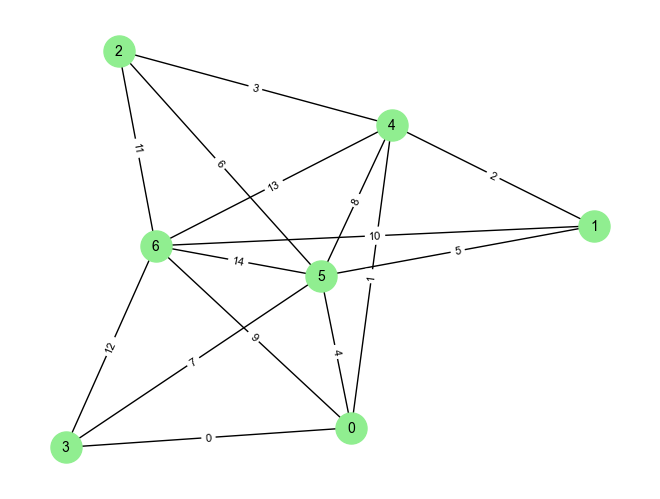

In [8]:
plot_graph(G.graph)

In [9]:
list(G.graph.iterEdges())

[(0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 5),
 (3, 6),
 (4, 5),
 (4, 6),
 (5, 6)]

In [10]:
import matplotlib.pyplot as plt

In [11]:
layout

{0: array([ 0.21321771, -0.79161279]),
 1: array([1.        , 0.14417575]),
 2: array([-0.53941074,  0.95542912]),
 3: array([-0.71201722, -0.88236658]),
 4: array([0.34411964, 0.61211257]),
 5: array([ 0.11460341, -0.0891842 ]),
 6: array([-0.42051281,  0.05144612])}

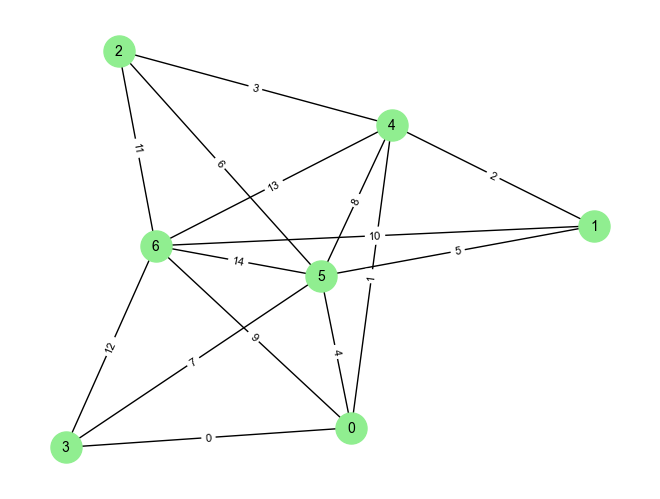

[(0, 1), (0, 3), (0, 2), (0, 5), (0, 6), (0, 4), (1, 5), (1, 6), (1, 4), (2, 6), (2, 4), (3, 6), (3, 4), (4, 5), (4, 6)]


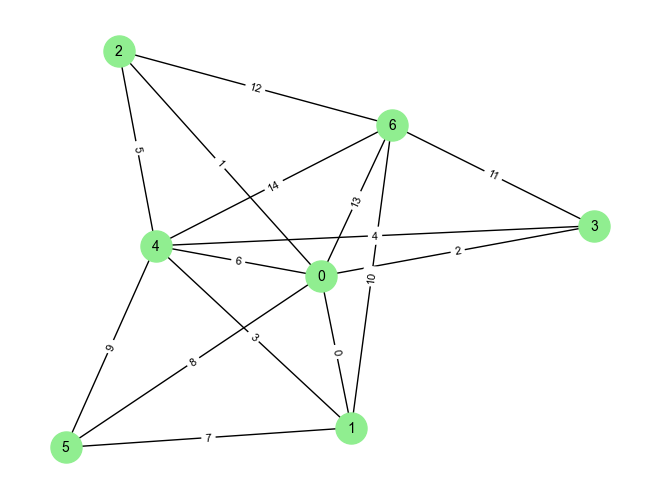

[(0, 4), (0, 6), (0, 3), (1, 4), (1, 6), (1, 3), (2, 5), (2, 4), (2, 6), (2, 3), (3, 5), (3, 4), (3, 6), (4, 6), (5, 6)]


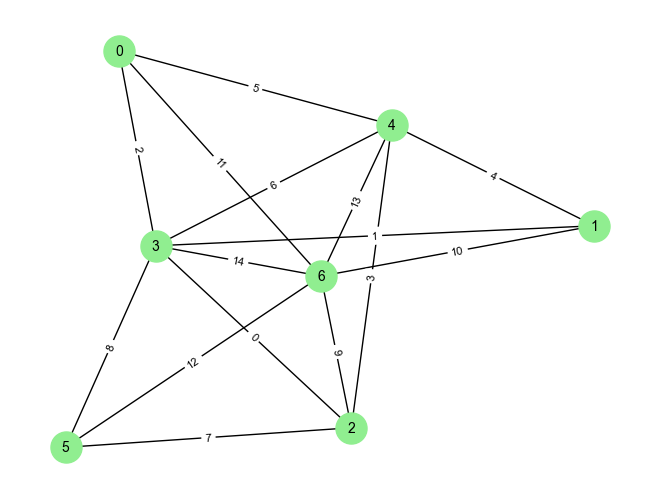

[(0, 6), (0, 2), (0, 1), (1, 6), (1, 3), (1, 5), (1, 4), (1, 2), (2, 6), (2, 3), (2, 5), (2, 4), (3, 4), (4, 6), (4, 5)]


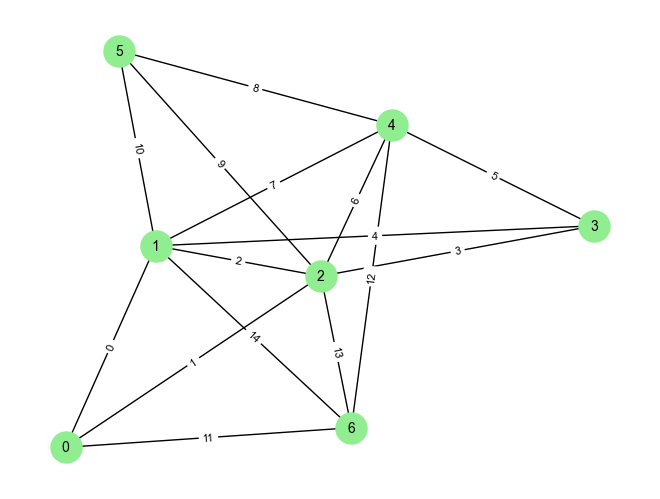

[(0, 1), (0, 6), (0, 2), (0, 4), (0, 5), (0, 3), (1, 4), (1, 5), (1, 3), (2, 5), (2, 3), (3, 6), (3, 4), (3, 5), (5, 6)]


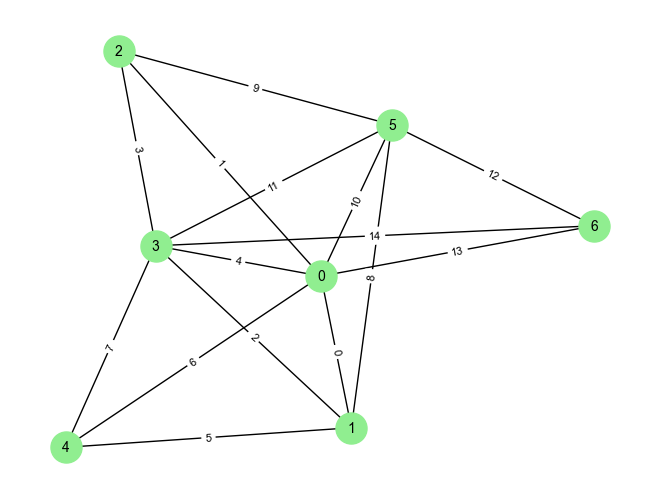

[(0, 6), (0, 4), (0, 3), (0, 2), (0, 5), (0, 1), (1, 6), (1, 4), (1, 3), (1, 2), (1, 5), (2, 6), (3, 5), (4, 5), (5, 6)]


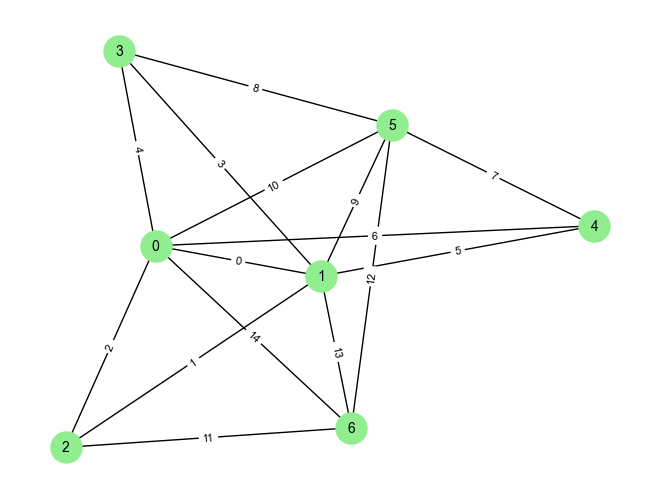

[(0, 3), (0, 6), (0, 5), (0, 1), (0, 2), (1, 3), (1, 6), (1, 5), (1, 4), (1, 2), (2, 3), (2, 6), (2, 5), (2, 4), (3, 4)]


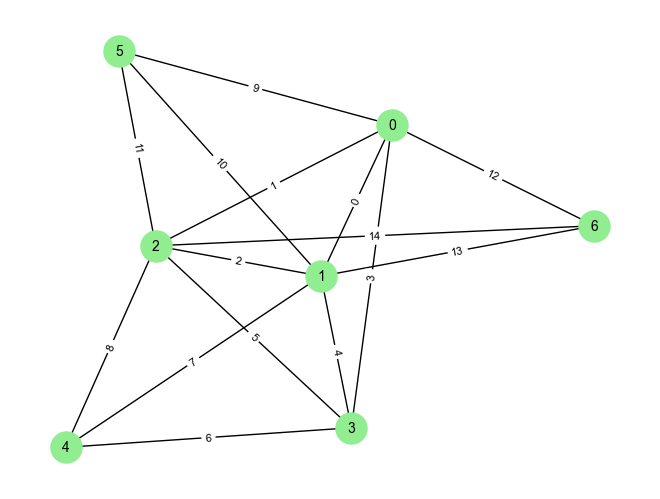

[(0, 4), (0, 1), (0, 6), (0, 3), (0, 5), (0, 2), (1, 5), (1, 2), (2, 4), (2, 6), (2, 3), (2, 5), (3, 4), (4, 5), (5, 6)]


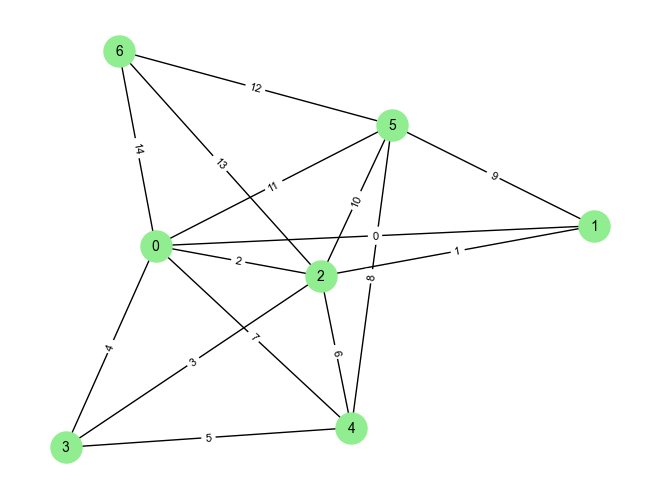

[(0, 6), (0, 2), (0, 3), (1, 5), (1, 2), (1, 3), (2, 5), (2, 4), (2, 6), (2, 3), (3, 5), (3, 4), (3, 6), (4, 6), (5, 6)]


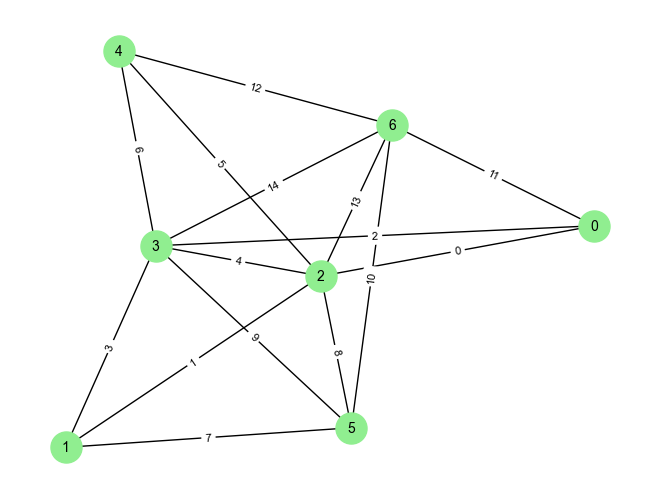

[(0, 1), (0, 2), (0, 5), (0, 6), (0, 4), (0, 3), (1, 6), (1, 4), (1, 3), (2, 4), (2, 3), (3, 5), (3, 6), (3, 4), (4, 5)]


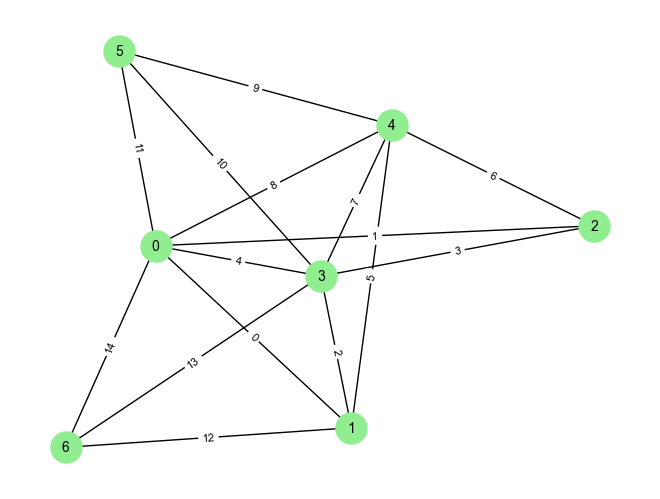

[(0, 1), (0, 6), (0, 5), (0, 3), (0, 2), (0, 4), (1, 3), (1, 2), (1, 4), (2, 6), (2, 5), (2, 4), (3, 4), (4, 6), (4, 5)]


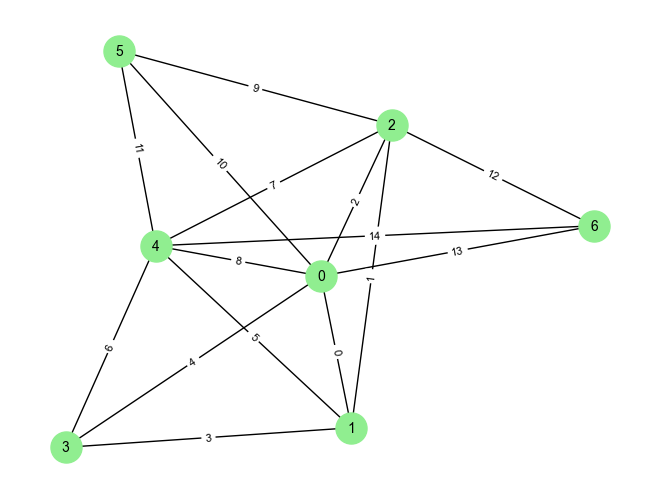

In [12]:
embeddings = [np.array(embedding_fun(G))]
plot_graph(G.graph, layout=layout)
plt.show()

for i in range(10):
    perm_graph, perm_layout = permute_graph(G.graph, layout)
    print(list(perm_graph.iterEdges()))
    G_perm = Graph("", 1, perm_graph, k_graphs={})
    emb = np.array(embedding_fun(G_perm))
    plot_graph(G_perm.graph, layout=perm_layout)
    plt.show()

    for j in range(i):
        if not np.allclose(embeddings[j], emb):
            print(embeddings[j], emb)
            print('-' * 20)

        # print(*embeddings, sep='\n')
    embeddings.extend([emb])
    

In [13]:
from src.descriptors.embeddings import get_function


0
[0.00500038 0.00500038 0.0050005  0.0050005  0.0050005  0.0050005 ]


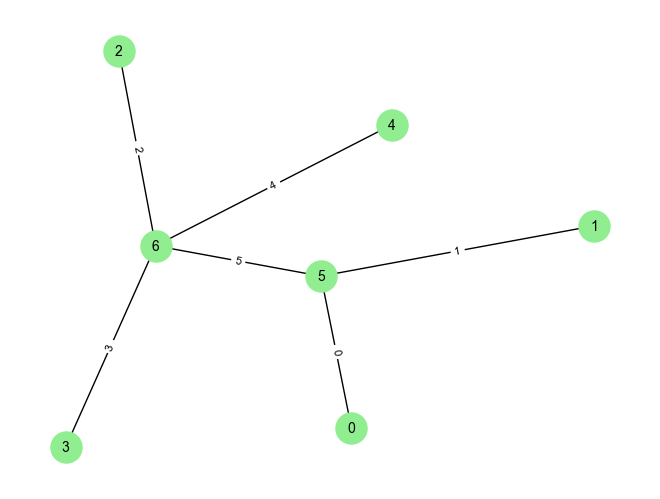

1
[0.00500013 0.00500013 0.0050005  0.0050005  0.0050005  0.0050005 ]


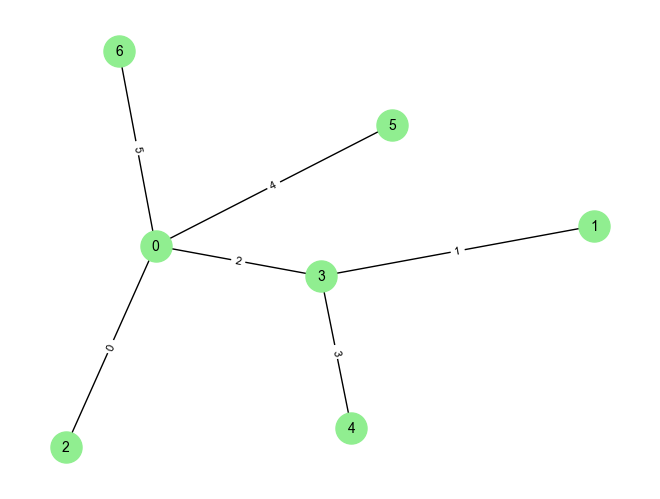

ValueError: 

In [14]:
descriptor_name = 'katz_index'
test_function = get_function(descriptor_name)
random.seed(1234)
for G in dataset:
    embeddings = [np.sort(np.array(test_function(G)))]
    graphs = [G]
    layouts = [layout]

    for i in range(10):
        perm_graph, perm_layout = permute_graph(G.graph, layout)

        G_perm = Graph("", 1, perm_graph, k_graphs={})
        graphs.append(G_perm)
        layouts.append(perm_layout)
        emb = np.sort(np.array(test_function(G_perm)))
        for j in range(i):
            if not np.allclose(embeddings[j], emb):
                plot_graph(graphs[j].graph, layouts[j])
                print(j)
                print(embeddings[j])
                plt.show()
                print(i)
                plot_graph(G_perm.graph, perm_layout)
                print(emb)
                plt.show()
                f"Descriptor '{descriptor_name}' is not permutation-invariant {embeddings[j], emb}"
                raise ValueError
        embeddings.extend([emb])

In [14]:
def simulate(A):
    print(*A, sep='\n')
    print('=' * 20)

    s = 0
    for k in range(1, 6):
        print(*(A * 0.005), sep='\n')
        print()
        s += (A[i,j] + A[j,i]) * 0.005
        A = A @ A * 0.005
    print(s)

In [15]:
i,j = 1, 2

A = nk.algebraic.adjacencyMatrix(graphs[j].graph, "dense").astype(np.float64)
simulate(A)

[0. 1. 1. 0.]
[1. 0. 0. 0.]
[1. 0. 0. 1.]
[0. 0. 1. 0.]
[0.    0.005 0.005 0.   ]
[0.005 0.    0.    0.   ]
[0.005 0.    0.    0.005]
[0.    0.    0.005 0.   ]

[5.0e-05 0.0e+00 0.0e+00 2.5e-05]
[0.0e+00 2.5e-05 2.5e-05 0.0e+00]
[0.0e+00 2.5e-05 5.0e-05 0.0e+00]
[2.5e-05 0.0e+00 0.0e+00 2.5e-05]

[3.125e-09 0.000e+00 0.000e+00 1.875e-09]
[0.000e+00 1.250e-09 1.875e-09 0.000e+00]
[0.000e+00 1.875e-09 3.125e-09 0.000e+00]
[1.875e-09 0.000e+00 0.000e+00 1.250e-09]

[1.328125e-17 0.000000e+00 0.000000e+00 8.203125e-18]
[0.000000e+00 5.078125e-18 8.203125e-18 0.000000e+00]
[0.000000e+00 8.203125e-18 1.328125e-17 0.000000e+00]
[8.203125e-18 0.000000e+00 0.000000e+00 5.078125e-18]

[2.43682861e-34 0.00000000e+00 0.00000000e+00 1.50604248e-34]
[0.00000000e+00 9.30786133e-35 1.50604248e-34 0.00000000e+00]
[0.00000000e+00 1.50604248e-34 2.43682861e-34 0.00000000e+00]
[1.50604248e-34 0.00000000e+00 0.00000000e+00 9.30786133e-35]

5.0003750000016406e-05


In [16]:
i,j = 0, 1

B = nk.algebraic.adjacencyMatrix(G_perm.graph, "dense")
simulate(B)

[0. 1. 0. 0.]
[1. 0. 1. 0.]
[0. 1. 0. 1.]
[0. 0. 1. 0.]
[0.    0.005 0.    0.   ]
[0.005 0.    0.005 0.   ]
[0.    0.005 0.    0.005]
[0.    0.    0.005 0.   ]

[2.5e-05 0.0e+00 2.5e-05 0.0e+00]
[0.0e+00 5.0e-05 0.0e+00 2.5e-05]
[2.5e-05 0.0e+00 5.0e-05 0.0e+00]
[0.0e+00 2.5e-05 0.0e+00 2.5e-05]

[1.250e-09 0.000e+00 1.875e-09 0.000e+00]
[0.000e+00 3.125e-09 0.000e+00 1.875e-09]
[1.875e-09 0.000e+00 3.125e-09 0.000e+00]
[0.000e+00 1.875e-09 0.000e+00 1.250e-09]

[5.078125e-18 0.000000e+00 8.203125e-18 0.000000e+00]
[0.000000e+00 1.328125e-17 0.000000e+00 8.203125e-18]
[8.203125e-18 0.000000e+00 1.328125e-17 0.000000e+00]
[0.000000e+00 8.203125e-18 0.000000e+00 5.078125e-18]

[9.30786133e-35 0.00000000e+00 1.50604248e-34 0.00000000e+00]
[0.00000000e+00 2.43682861e-34 0.00000000e+00 1.50604248e-34]
[1.50604248e-34 0.00000000e+00 2.43682861e-34 0.00000000e+00]
[0.00000000e+00 1.50604248e-34 0.00000000e+00 9.30786133e-35]

0.01


In [17]:
from itertools import permutations

In [18]:
n = 5
dataset_name = f"graph{n}c"
dataset = Dataset(dataset_name)

possible_perms = list(permutations(range(n)))

all_graphs = []
for G in dataset:
    graphs = []

    for perm in possible_perms:
        perm_graph, perm_layout = permute_graph(G.graph)

        G_perm = Graph("", 1, perm_graph, k_graphs={})
        graphs.append(G_perm)

    all_graphs.append(graphs)


In [19]:
len(all_graphs[0])

120

In [22]:
descriptor_name = 'betweenness'
test_function = get_function(descriptor_name)

results = []
for i, graphs in enumerate(all_graphs):
    embeddings = []
    count = []
    for G_perm in graphs:

        emb = np.sort(np.array(test_function(G_perm)))
        for j, prev_emb in enumerate(embeddings):
            if np.allclose(embeddings[j], emb):
                count[j] += 1
                break

        else:
            embeddings.append(emb)
            count.append(1)
    # print(embeddings)
    # print(count)
    # print(max(count) / len(graphs))
    # print('========')
    results.append(max(count) / len(graphs))
print(min(results))



1.0
